# Customer Personality Analysis
In this project I will complete a customer segmentation workflow that allows for a company to better market their products, aim campaigns at specific segments. The dataset has 29 features belonging to these four categories: personal information (e.g. year of birth, education), purchase history (e.g. amount of money spent on sweets), promotion related information (e.g which campaign offer was accepted by a customer) and place of purchase (number of products bought in stores, through a website etc.). The dataset is publicly available on kaggle.

In [1]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Data exploration

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

We can see that in the income column there are less non-null values than any other. Since the difference is not big we can simply drop the rows containing null values.

In [3]:
df.dropna(inplace=True)
df.shape

(2216, 29)

In [4]:
numerical_cols = []
for c in list(df.columns):
    if df[c].dtype == "float64" or df[c].dtype == "int64":
        numerical_cols.append(c)
numerical_cols

['ID',
 'Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

ID is not usable for any model, therefore it should be dropped.

In [5]:
df.drop("ID", axis=1, inplace=True)
numerical_cols.remove("ID")

Since clustering heavily relies on distance metrics, features of different magnitudes can heavily distort correct distance calculations, so feature scaling is very important. Before that, we should differentiate the continuous values from the categorical ones and do the scaling only on the continuous features afterwards.

In [6]:
value_counts_results = []
for c in numerical_cols:
    value_counts_results.append(len(list(df[c].value_counts())))
sorted(value_counts_results)

[1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 14,
 14,
 15,
 15,
 16,
 59,
 100,
 158,
 176,
 182,
 212,
 554,
 776,
 1974]

We can see there is a heavy jump in values after 16. The next number is 59. Let's look at those columns specifically.

In [7]:
idx = value_counts_results.index(16)
pd.DataFrame(df.iloc[:,idx]).sample()

,NumWebPurchases
1406,6


In [8]:
idx = value_counts_results.index(59)
pd.DataFrame(df.iloc[:,idx]).sample()

,Year_Birth
933,1989


16 different values belonged to the number of web purchases which should be treated as continuous. Let's look at the column containing 14 different values.

In [9]:
idx = value_counts_results.index(14)
pd.DataFrame(df.iloc[:,idx]).sample()

,MntGoldProds
1791,1


There is another column with 14 unique values as well.

In [10]:
value_counts_results.reverse()
idx = value_counts_results.index(14)
pd.DataFrame(df.iloc[:,idx]).sample()

,MntMeatProducts
20,73


Both are continuous values, thus the categorical features are the ones with 3 unique values or less.

In [11]:
categorical_cols = []
for c in numerical_cols:
    if len(list(df[c].value_counts())) <= 3:
        categorical_cols.append(c)
categorical_cols

['Kidhome',
 'Teenhome',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

In [12]:
numerical_cols = [x for x in numerical_cols if x not in categorical_cols]
numerical_cols

['Year_Birth',
 'Income',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth']

The next step is to have a look at the non-numerical features.

In [13]:
non_num_cols = [x for x in list(df.columns) if x not in numerical_cols and x not in categorical_cols]
non_num_cols

['Education', 'Marital_Status', 'Dt_Customer']

In [14]:
for c in non_num_cols:
    print(df[c].value_counts())

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64
Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Dt_Customer
31-08-2012    12
12-05-2014    11
14-02-2013    11
12-09-2012    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 662, dtype: int64


Marital status is a non_binary categorical feature, it should be encoded via one-hot encoding. Education is also non-binary, but since it expresses higher or lower levels of education, ordinal encoding should be used. As for the date, I will compute the number of days passed since that date, then treat it as a continuous value.

## Data preparation

In this phase I will do the necessary transformations as discussed above. However, in order to avoid data leakage, the dataset must be split first.

In [15]:
from sklearn.model_selection import train_test_split

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
today = pd.to_datetime("today")
df["Dt_Customer"] = (today - df["Dt_Customer"]).dt.days

X_train, X_test = train_test_split(df, test_size=0.25, random_state=42, shuffle=True)
X_train.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
842,1988,Graduation,Single,34176.0,1,0,4494,12,5,7,...,6,0,0,0,0,0,0,3,11,0
49,1954,PhD,Married,72550.0,1,1,5044,39,826,50,...,8,0,0,0,0,0,0,3,11,0
1862,1979,Graduation,Single,61825.0,0,1,4772,56,162,50,...,4,0,0,0,0,0,0,3,11,0
1875,1987,2n Cycle,Single,23830.0,0,0,4588,3,1,8,...,7,0,0,0,0,0,0,3,11,0
305,1961,Master,Married,80950.0,0,0,4904,44,525,147,...,2,0,0,0,1,0,0,3,11,0


### Feature scaling

In [16]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train[numerical_cols] = ss.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = ss.transform(X_test[numerical_cols])
X_train.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
842,1.592682,Graduation,Single,-0.695237,1,0,4494,-1.270819,-0.890549,-0.493669,...,0.283075,0,0,0,0,0,0,3,11,0
49,-1.190141,PhD,Married,0.767668,1,1,5044,-0.335648,1.566480,0.570923,...,1.101285,0,0,0,0,0,0,3,11,0
1862,0.856053,Graduation,Single,0.358806,0,1,4772,0.253163,-0.420691,0.570923,...,-0.535135,0,0,0,0,0,0,3,11,0
1875,1.510835,2n Cycle,Single,-1.089650,0,0,4588,-1.582542,-0.902520,-0.468911,...,0.692180,0,0,0,0,0,0,3,11,0
305,-0.617207,Master,Married,1.087895,0,0,4904,-0.162468,0.665669,2.972444,...,-1.353345,0,0,0,1,0,0,3,11,0


In [17]:
ss = StandardScaler()
X_train["Dt_Customer"] = ss.fit_transform(X_train[["Dt_Customer"]])
X_test["Dt_Customer"] = ss.transform(X_test[["Dt_Customer"]])

X_train["Dt_Customer"].head()

842    -1.492869
49      1.205738
1862   -0.128846
1875   -1.031653
305     0.518820
Name: Dt_Customer, dtype: float64

## Encoding

We have seen previously that there were two non-binary categorical columns, and as we can see above the features Z cost contact and Z revenue are the only ones that are not 0-1 values. Let's see if this presumption is right.

In [18]:
print(df["Z_CostContact"].value_counts())
print(df["Z_Revenue"].value_counts())

Z_CostContact
3    2216
Name: count, dtype: int64
Z_Revenue
11    2216
Name: count, dtype: int64


Although the assumption was not right, we managed to identify the two attributes with only one value. As such, these have no information in regards to our predictions, therefore can be removed.

In [19]:
X_train.drop(["Z_CostContact", "Z_Revenue"], axis=1, inplace=True)
X_test.drop(["Z_CostContact", "Z_Revenue"], axis=1, inplace=True)
categorical_cols.remove("Z_CostContact")
categorical_cols.remove("Z_Revenue")

In [20]:
for c in categorical_cols:
    print(df[c].value_counts())

Kidhome
0    1283
1     887
2      46
Name: count, dtype: int64
Teenhome
0    1147
1    1018
2      51
Name: count, dtype: int64
AcceptedCmp3
0    2053
1     163
Name: count, dtype: int64
AcceptedCmp4
0    2052
1     164
Name: count, dtype: int64
AcceptedCmp5
0    2054
1     162
Name: count, dtype: int64
AcceptedCmp1
0    2074
1     142
Name: count, dtype: int64
AcceptedCmp2
0    2186
1      30
Name: count, dtype: int64
Complain
0    2195
1      21
Name: count, dtype: int64
Response
0    1883
1     333
Name: count, dtype: int64


Kidhome and Teenhome are the two features with three unique values. These signify the number of kids/teens in the household. After having scaled the numerical values, the value 2 might throw the distance metrics off by a little. For now, I will leave them as they are, but it is important to keep in mind during the final model evaluation.

In [21]:
non_num_cols

['Education', 'Marital_Status', 'Dt_Customer']

The final step of the encoding phase is to deal with education and marital status as discussed above.

In [22]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

oe = OrdinalEncoder(categories=[["Basic", "Graduation", "2n Cycle", "Master", "PhD"]])
X_train["Education"] = oe.fit_transform(X_train[["Education"]])
X_test["Education"] = oe.transform(X_test[["Education"]])
X_train["Education"] = ss.fit_transform(X_train[["Education"]]) ## since the values go up to 5 after encoding, it would throw off the distance metrics if not scaled
X_test["Education"] = ss.transform(X_test[["Education"]])

ohe = OneHotEncoder(sparse_output=False)
X_train_encode = pd.DataFrame(
    ohe.fit_transform(X_train[["Marital_Status"]]),
    columns=ohe.get_feature_names_out(["Marital_Status"]),
    index=X_train.index
)
X_test_encode = pd.DataFrame(
    ohe.transform(X_test[["Marital_Status"]]),
    columns=ohe.get_feature_names_out(["Marital_Status"]),
    index=X_test.index
)

X_train = pd.concat([X_train.drop("Marital_Status", axis=1), X_train_encode], axis=1)
X_test = pd.concat([X_test.drop("Marital_Status", axis=1), X_test_encode], axis=1)

X_train.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Response,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
842,1.592682,-0.825343,-0.695237,1,0,-1.492869,-1.270819,-0.890549,-0.493669,-0.645892,...,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
49,-1.190141,1.500921,0.767668,1,1,1.205738,-0.335648,1.566480,0.570923,0.682579,...,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1862,0.856053,-0.825343,0.358806,0,1,-0.128846,0.253163,-0.420691,0.570923,-0.301306,...,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1875,1.510835,-0.049922,-1.089650,0,0,-1.031653,-1.582542,-0.902520,-0.468911,-0.727504,...,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
305,-0.617207,0.725500,1.087895,0,0,0.518820,-0.162468,0.665669,2.972444,-0.246897,...,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Modeling

In this section I will compare multiple clustering algorithms and choose the most suitable for this specific problem.

### K-means
As k-means requires only one parameter to work it is relatively easy to use, and also easy to interpret. Finding the best k value is the only challenge. In order to find it I will use the elbow method.

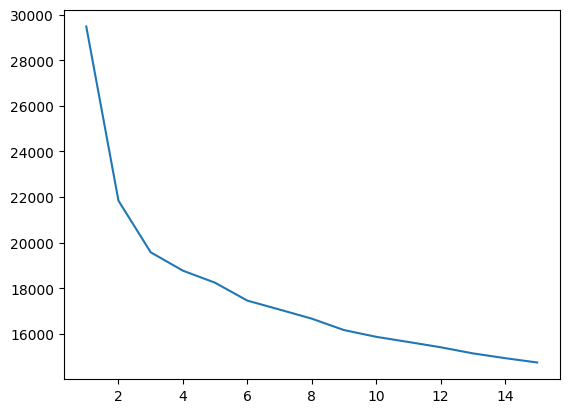

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k = range(1, 16)
inertia = []
for k_value in k:
    kmeans = KMeans(n_clusters=k_value, random_state=42)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

plt.plot(k, inertia)

There isn't a very obvious elbow in this plot, rather there are multiple less visible elbows. To keep the interpretation relatively simple, I will choose 3 to be the number of clusters.

In [24]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train)
print(f"Inertia: {round(kmeans.inertia_,2)}")

silhouette = silhouette_score(X_train, kmeans.labels_)
print(f"Silhouette score: {round(silhouette, 2)}")

Inertia: 19579.74
Silhouette score: 0.19


We can see that the high inertia suggest high distance inside clusters, which aligns well with a close-to-zero silhouette score, suggesting overlapping clusters. All-in-all it seems k-means did not manage to separate the clusters clearly enough for it to be considered suitable for production.

### Mean shift
Instead of relying on distance let's see if a density-based approach is more successful.

In [25]:
from sklearn.cluster import MeanShift

ms = MeanShift()
ms.fit(X_train)

silhouette = silhouette_score(X_train, ms.labels_)
print(f"Silhouette score: {round(silhouette, 2)}")

Silhouette score: 0.2


Mean shift managed to separate clusters a little more accurately. As no specific bandwidth was given, the algorithm used an estimation implicitly. Since this algorithm is very computationally expensive, trying different bandwidth values takes lots of time. The estimation can be done explicitly and the parameters of that function can be optimized which could eventually lead to better clustering. For now we will leave this model at its base from.

### DBSCAN

Another density-based approach, which also has to ability to identify outliers. On the downside, this has two parameters to tune and has no prediction ability.

In [26]:
from sklearn.cluster import DBSCAN

#dbs = DBSCAN()
#dbs.fit(X_train)

#silhouette = silhouette_score(X_train, dbs.labels_)
#print(f"Silhouette score: {round(silhouette, 2)}")

In its base form, DBSCAN clusters all point into one big cluster, thus silhouette score calculations fail. Let's tune the epsilon hyperparameter.

In [27]:
import numpy as np

sils = []
eps = range(2, 15)
cluster_num = []

for e in eps:
    dbs = DBSCAN(eps=e)
    dbs.fit(X_train)

    sils.append(round(silhouette_score(X_train, dbs.labels_),2))
    cluster_num.append(len(np.unique(dbs.labels_)))
print(sils)
print(cluster_num)

[-0.09, 0.06, 0.38, 0.54, 0.57, 0.57, 0.64, 0.66, 0.76, 0.76, 0.76, 0.76, 0.76]
[6, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


As we see here, although DBSCAN can achieve higher silhouette score values, it is due to inappropriate clustering. Two clusters found probably mean one big cluster and some outliers. which is not a good result at all. Let's see if this can be fixed with tuning the min_samples parameter.

In [28]:
sils = []
eps = range(2, 15)
n_samples = range(2, 15)
cluster_num = []

for e in eps:
    for s in n_samples:
        dbs = DBSCAN(eps=e, min_samples=s)
        dbs.fit(X_train)

        sils.append(round(silhouette_score(X_train, dbs.labels_),2))
        cluster_num.append(len(np.unique(dbs.labels_)))

In [29]:
print(len(np.unique(ms.labels_)))

10


Mean shift found 10 clusters. Let's review the silhouette scores for similar amounts:

In [30]:
for idx, val in enumerate(cluster_num):
    if val >= 6 and val <= 12:
        print(f"With {val} clusters DBSCAN achieved a silhouette score of {sils[idx]}")

With 11 clusters DBSCAN achieved a silhouette score of -0.13
With 9 clusters DBSCAN achieved a silhouette score of -0.1
With 6 clusters DBSCAN achieved a silhouette score of -0.09
With 8 clusters DBSCAN achieved a silhouette score of 0.09
With 6 clusters DBSCAN achieved a silhouette score of 0.2


DBSCAN managed to achieve the same score as mean shift, forming 6 clusters.

## Conclusion
Looking at the metrics DBSCAN with fine-tuning performed as well as mean shift in its base form. It is also important to note, that mean shift has prediction capabilities, with which the company can immediately figure out what kind of campaign to aim at new customers. I would recommend moving forward with mean shift after appropriate fine-tuning.